<a href="https://colab.research.google.com/github/rinviriti/AI-ML-Learning-Journey/blob/main/10_computer_vision/image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Classification Workflow

Image classification is a Computer Vision task where a model predicts the category of an image.

Examples:

- Cat vs Dog
- Normal vs Pneumonia X-ray
- Benign vs Malignant Skin Lesion
- Brain Tumor vs Normal MRI

In this notebook, we will build a basic image classification workflow using TensorFlow.

## Workflow

A typical image classification pipeline includes:

1. Load dataset
2. Preprocess images
3. Build model
4. Train model
5. Evaluate model
6. Make predictions

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

## Loading Dataset

We will use Fashion MNIST as a beginner-friendly image dataset.

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data: (60000, 28, 28)
Testing Data: (10000, 28, 28)


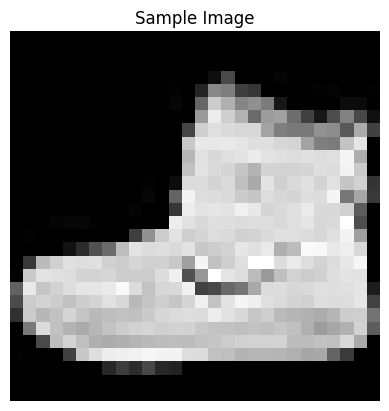

In [3]:
plt.imshow(X_train[0], cmap="gray")
plt.title("Sample Image")
plt.axis("off")
plt.show()

## Preprocessing

Pixel values range from 0 to 255.

We normalize the values to 0 to 1 so the model can train more efficiently.

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

## Building a Simple Neural Network

This model receives image pixels as input and predicts one of 10 classes.

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Training the Model

In [7]:
model.fit(
    X_train,
    y_train,
    epochs=3,
    validation_split=0.2
)

Epoch 1/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8173 - loss: 0.5225 - val_accuracy: 0.8507 - val_loss: 0.4225
Epoch 2/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8604 - loss: 0.3889 - val_accuracy: 0.8612 - val_loss: 0.3915
Epoch 3/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8731 - loss: 0.3501 - val_accuracy: 0.8714 - val_loss: 0.3574


## Evaluating the Model

In [8]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8638 - loss: 0.3837
Test Accuracy: 0.8637999892234802


## Making a Prediction

In [9]:
prediction = model.predict(X_test[:1])

predicted_class = prediction.argmax()

print("Predicted Class:", predicted_class)
print("Actual Class:", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Predicted Class: 9
Actual Class: 9


# Summary

In this notebook I learned:

- What image classification is
- How to load an image dataset
- How to normalize image data
- How to build a simple classification model
- How to train and evaluate the model
- How image classification connects to Medical AI

This workflow is a basic foundation for future projects such as MobileSkinXAI.